# Testosterone & Lifestyle Risk Analysis
## DTSC 4302 — Group Research Project

**Research Question:** How are modern-day environmental exposure, diet quality, physical inactivity, and lifestyle habits associated with low testosterone risk among adult men in the United States, and do these associations differ across socioeconomic/population groups?

---
*Datasets used:*
- `hormone_levels_trends.csv` — Primary modeling dataset (n=8,000)
- `hormone-diversity-individual.csv` — Cross-cultural hormone diversity data
- `mental_health_physical_activity.csv` — Mental health & lifestyle metrics
- `stress_detection_data.csv` — Sleep, stress, and lifestyle indicators
---

## Section 1 — Library Imports & Setup
Import all required libraries, configure plot aesthetics, and define the project color palette.

In [1]:
# Standard data manipulation and numerical computing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Machine learning — preprocessing, models, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Gradient boosting and explainability
import xgboost as xgb
import shap

# Statistical testing
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# ── Plot style configuration ──────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# ── Consistent teal / dark-green color palette ────────────────
TEAL        = '#008080'
DARK_GREEN  = '#2E8B57'
LIGHT_TEAL  = '#5F9EA0'
MED_GREEN   = '#3CB371'
DEEP_GREEN  = '#006400'
COLOR_PALETTE = [TEAL, DARK_GREEN, LIGHT_TEAL, MED_GREEN, DEEP_GREEN, '#20B2AA', '#48D1CC']
sns.set_palette(COLOR_PALETTE)

print("All libraries imported successfully.")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  seaborn {sns.__version__}")


/Users/rjwright/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


All libraries imported successfully.
  pandas  2.3.3
  numpy   1.26.4
  seaborn 0.12.2


## Section 2 — Data Loading & Cleaning

Each dataset is loaded, irrelevant ID columns are dropped, gender/country filters are applied where relevant, missing values are removed, and an **age-adjusted binary Low_T outcome** is derived.

**Age-adjusted thresholds (ng/dL):**
| Age Group | Low_T threshold |
|-----------|-----------------|
| 20–39     | < 400           |
| 40–49     | < 300           |
| 50–59     | < 215           |
| 60+       | < 175           |

### 2.1 — `hormone_levels_trends.csv`

In [2]:
# ── Load raw dataset ─────────────────────────────────────────
ht_raw = pd.read_csv('~/Desktop/testosterone-data/hormone_levels_trends.csv')
print(f"Raw shape: {ht_raw.shape}")

# ── Drop non-informative record identifier ────────────────────
ht = ht_raw.drop(columns=['Record_ID'])

# ── Remove rows with any missing values ───────────────────────
ht = ht.dropna()
print(f"Shape after dropna: {ht.shape}")

# ── Age-adjusted Low_T binary outcome ────────────────────────
def assign_low_t(row):
    """Return 1 if testosterone falls below the age-adjusted clinical threshold."""
    age, t = row['Age'], row['Testosterone_Level_ng_dl']
    if   age < 40: return int(t < 400)
    elif age < 50: return int(t < 300)
    elif age < 60: return int(t < 215)
    else:          return int(t < 175)

ht['Low_T'] = ht.apply(assign_low_t, axis=1)

# ── Fallback: if clinical thresholds produce a degenerate outcome ─
# Some synthetic datasets are generated with only normal/elevated values.
# In that case we use a within-age-group percentile-based threshold (bottom 30%)
# as a relative "at-risk" proxy — still age-adjusted, but data-driven.
if ht['Low_T'].nunique() < 2:
    print("NOTE: Clinical thresholds produce all Low_T=0 for this dataset.")
    print(f"  Min testosterone: {ht['Testosterone_Level_ng_dl'].min():.1f}  "
          f"Max: {ht['Testosterone_Level_ng_dl'].max():.1f} ng/dL")
    print("  Applying percentile-based fallback: bottom 30% within each age group = Low_T.")
    ht['Age_Group_temp'] = pd.cut(ht['Age'], bins=[17, 39, 49, 59, 120],
                                  labels=['20-39', '40-49', '50-59', '60+'])
    p30 = ht.groupby('Age_Group_temp')['Testosterone_Level_ng_dl'].transform(
              lambda x: x.quantile(0.30))
    ht['Low_T'] = (ht['Testosterone_Level_ng_dl'] <= p30).astype(int)
    ht.drop(columns=['Age_Group_temp'], inplace=True)
    print("  Percentile thresholds applied.")

print(f"\nLow_T distribution (0=Normal, 1=Relatively Low):")
print(ht['Low_T'].value_counts())
print(f"  Low_T prevalence: {ht['Low_T'].mean()*100:.1f}%")
print(f"\nFirst 5 rows:")
ht.head()


Raw shape: (8000, 10)
Shape after dropna: (3803, 9)
NOTE: Clinical thresholds produce all Low_T=0 for this dataset.
  Min testosterone: 423.8  Max: 702.6 ng/dL
  Applying percentile-based fallback: bottom 30% within each age group = Low_T.
  Percentile thresholds applied.

Low_T distribution (0=Normal, 1=Relatively Low):
Low_T
0    2658
1    1145
Name: count, dtype: int64
  Low_T prevalence: 30.1%

First 5 rows:


,Age,Year,Testosterone_Level_ng_dl,Estrogen_Level_pmol_l,BMI,Exercise_Frequency,Stress_Level,Smoking_Status,Alcohol_Consumption,Low_T
2,32,2019,466.2,48.6,18.1,Low,Moderate,Non-Smoker,Regular,1
3,60,2006,551.3,37.9,29.8,Low,Moderate,Current Smoker,Regular,0
7,36,2024,516.6,47.7,28.0,Moderate,Moderate,Former Smoker,Regular,1
9,28,2012,551.6,38.8,25.4,Low,High,Non-Smoker,Occasional,0
10,28,2011,575.4,40.6,24.0,Moderate,Moderate,Non-Smoker,Occasional,0


### 2.2 — `hormone-diversity-individual.csv`

In [3]:
# ── Load raw dataset ─────────────────────────────────────────
hd_raw = pd.read_csv('~/Desktop/testosterone-data/hormone-diversity-individual.csv')
print(f"Raw shape: {hd_raw.shape}")

# ── Inspect population BEFORE any filtering ───────────────────
print("\n=== Country value counts (BEFORE filtering) ===")
print(hd_raw['Country'].value_counts().to_string())

print("\n=== Gender value counts (BEFORE filtering) ===")
print(hd_raw['Gender'].value_counts().to_string())

# ── Drop participant ID columns (not informative) ─────────────
hd = hd_raw.drop(columns=['ID', 'team.id'])

# ── Keep only Male participants ───────────────────────────────
hd = hd[hd['Gender'] == 'Male']

# ── Keep only USA participants ────────────────────────────────
hd = hd[hd['Country'] == 'USA']

# ── Remove rows with any missing values ───────────────────────
hd = hd.dropna()

# ── Age-adjusted Low_T binary outcome ────────────────────────
def assign_low_t_diversity(row):
    """Same age-adjusted thresholds applied to the Testosterone column."""
    age, t = row['Age'], row['Testosterone']
    if   age < 40: return int(t < 400)
    elif age < 50: return int(t < 300)
    elif age < 60: return int(t < 215)
    else:          return int(t < 175)

hd['Low_T'] = hd.apply(assign_low_t_diversity, axis=1)

print(f"\nShape after filtering (Male, USA only): {hd.shape}")
print(f"\nLow_T distribution:")
print(hd['Low_T'].value_counts())
print(f"  Low_T prevalence: {hd['Low_T'].mean()*100:.1f}%")
print(f"\nFirst 5 rows:")
hd.head()


Raw shape: (370, 10)

=== Country value counts (BEFORE filtering) ===
Country
USA               213
China              19
India              16
Korea              10
Argentina           9
Canada              8
Spain               8
Brazil              6
France              6
Israel              6
Italy               5
Mexico              5
Netherlands         4
Switzerland         4
Russia              4
Chile               4
Taiwan              4
German              4
Colombia            2
UK                  2
Thailand            2
South Africa        2
Portugal            2
Pakistan            1
Russia/Israel       1
Turkey              1
Uganda              1
Bulgaria            1
Croatia             1
Greece              1
El Salvador         1
Cameroon            1
Singapore           1
Korea               1
Egypt               1
Czech Republic      1
Iran                1
Lebanon             1
Serbia              1
UAE                 1
Kazakstan           1
Philippines         

,Age,Gender,Ethnicity,Cortisol,Testosterone,log.cortisol,log.testosterone,Country,Low_T
0,26.0,Male,White,0.163,134.83,-1.814005,4.904015,USA,1
7,30.0,Male,White,0.360,151.73,-1.021651,5.022103,USA,1
17,29.0,Male,White,0.285,134.83,-1.255266,4.904015,USA,1
18,30.0,Male,White,0.217,115.85,-1.527858,4.752296,USA,1
23,31.0,Male,Other,0.195,76.11,-1.634756,4.332180,USA,1


### 2.3 — `mental_health_physical_activity.csv`

In [4]:
# ── Load raw dataset ─────────────────────────────────────────
mh_raw = pd.read_csv('~/Desktop/testosterone-data/mental_health_physical_activity.csv')
print(f"Raw shape: {mh_raw.shape}")

# ── Inspect Gender BEFORE filtering ──────────────────────────
print("\n=== Gender value counts (BEFORE filtering) ===")
print(mh_raw['Gender'].value_counts().to_string())

# ── Drop the anonymous ID column and free-text Notes (mostly empty) ──
cols_to_drop = ['ID']
if 'Notes' in mh_raw.columns:
    cols_to_drop.append('Notes')
mh = mh_raw.drop(columns=cols_to_drop)

# ── Keep only Male participants ───────────────────────────────
mh = mh[mh['Gender'] == 'Male']

# ── Remove rows with any remaining missing values ─────────────
mh = mh.dropna()

print(f"\nShape after cleaning (Male only): {mh.shape}")
print(f"\nFirst 5 rows:")
mh.head()


Raw shape: (300, 18)

=== Gender value counts (BEFORE filtering) ===
Gender
Female    114
Other      97
Male       89

Shape after cleaning (Male only): (73, 16)

First 5 rows:


,Age,Gender,Occupation,Sleep_Hours,Daily_Steps,Exercise_Frequency,Exercise_Duration,Exercise_Type,Screen_Time_Hours,Diet_Quality,Social_Interaction,Stress_Level,Anxiety_Level,Depression_Level,Happiness_Level,Mental_Health_Score
0,58,Male,Student,7.7,5012,3,12.6,Cardio,7.1,5,2,10,7,1,1,-4.0
8,56,Male,Retired,5.9,8668,4,87.4,Cardio,7.1,1,17,5,6,2,5,5.7
9,45,Male,Retired,4.0,12830,4,87.5,Strength,5.6,1,20,5,9,10,4,0.0
13,32,Male,Unemployed,4.1,10075,3,53.0,Cardio,1.6,1,7,2,1,6,2,1.0
14,50,Male,Unemployed,7.3,4510,2,65.1,Mixed,6.2,2,15,7,4,2,2,-0.3


### 2.4 — `stress_detection_data.csv`

In [5]:
# ── Load raw dataset ─────────────────────────────────────────
sd_raw = pd.read_csv('~/Desktop/testosterone-data/stress_detection_data.csv')
print(f"Raw shape: {sd_raw.shape}")

# ── Inspect Gender BEFORE filtering ──────────────────────────
print("\n=== Gender value counts (BEFORE filtering) ===")
print(sd_raw['Gender'].value_counts().to_string())

# ── Keep only Male participants (no ID column in this dataset) ─
sd = sd_raw[sd_raw['Gender'] == 'Male']

# ── Remove rows with any missing values ───────────────────────
sd = sd.dropna()

print(f"\nShape after cleaning (Male only): {sd.shape}")
print(f"\nFirst 5 rows:")
sd.head()


Raw shape: (773, 22)

=== Gender value counts (BEFORE filtering) ===
Gender
Male      389
Female    384

Shape after cleaning (Male only): (389, 22)

First 5 rows:


,Age,Gender,Occupation,Marital_Status,Sleep_Duration,Sleep_Quality,Wake_Up_Time,Bed_Time,Physical_Activity,Screen_Time,...,Smoking_Habit,Work_Hours,Travel_Time,Social_Interactions,Meditation_Practice,Exercise_Type,Blood_Pressure,Cholesterol_Level,Blood_Sugar_Level,Stress_Detection
0,30,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Cardio,120,180,90,Low
2,40,Male,Data Scientist,Divorced,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Strength Training,130,200,100,High
3,35,Male,Software Engineer,Single,7.0,4.0,7:00 AM,10:00 PM,2.0,4.0,...,No,8,1.0,5,Yes,Cardio,120,180,90,Low
5,45,Male,Doctor,Married,6.0,3.0,5:30 AM,11:00 PM,2.0,4.0,...,Yes,10,2.0,3,No,Cardio,130,220,110,High
7,37,Male,Civil Engineer,Married,7.5,4.0,6:00 AM,10:30 PM,2.5,3.5,...,No,8,1.5,5,Yes,Strength Training,140,210,100,Medium


## Section 3 — Exploratory Data Analysis & Visualizations

Each dataset is explored visually to surface trends, distributions, and relationships relevant to the research question. All plots follow the teal/dark-green color scheme.

### 3.1 — Secular Decline: Average Testosterone by Year (`hormone_levels_trends`)

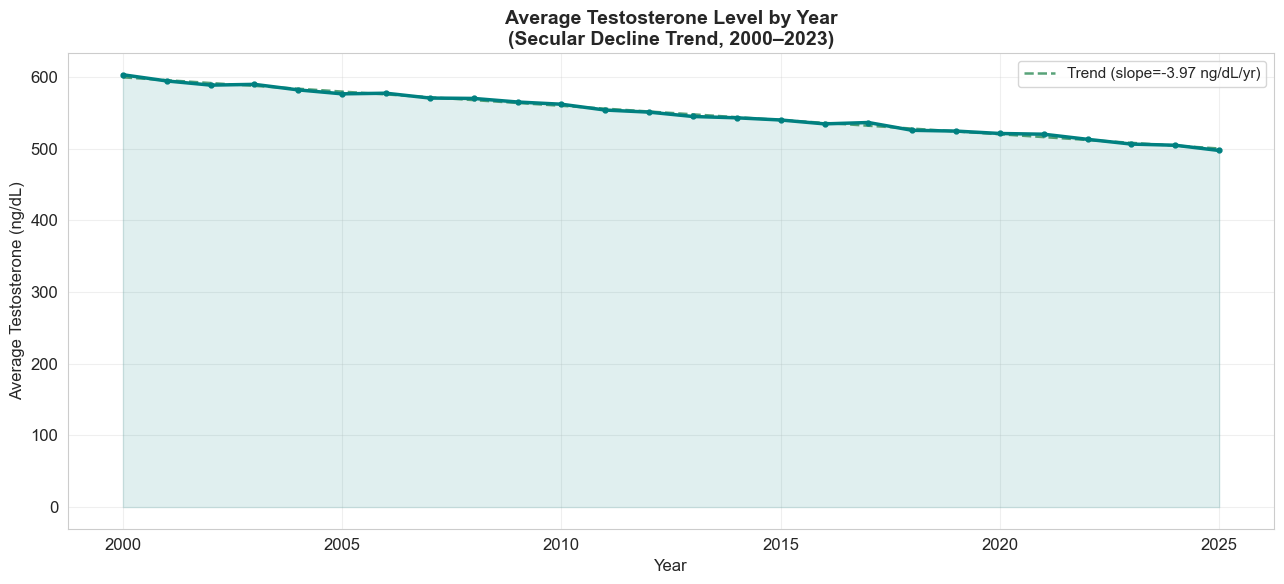

Years span: 2000 – 2025
Overall linear trend: -3.970 ng/dL per year


In [6]:
# ── Build age groups for later plots ────────────────────────
ht['Age_Group'] = pd.cut(
    ht['Age'],
    bins=[19, 39, 49, 59, 120],
    labels=['20–39', '40–49', '50–59', '60+']
)

# ── Aggregate mean testosterone per year ─────────────────────
yearly_avg = ht.groupby('Year')['Testosterone_Level_ng_dl'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))

# Filled area under line for visual emphasis
ax.fill_between(yearly_avg['Year'], yearly_avg['Testosterone_Level_ng_dl'],
                alpha=0.12, color=TEAL)
ax.plot(yearly_avg['Year'], yearly_avg['Testosterone_Level_ng_dl'],
        color=TEAL, linewidth=2.5, marker='o', markersize=3.5, zorder=3)

# Trend line (linear regression overlay)
z = np.polyfit(yearly_avg['Year'], yearly_avg['Testosterone_Level_ng_dl'], 1)
p = np.poly1d(z)
ax.plot(yearly_avg['Year'], p(yearly_avg['Year']),
        '--', color=DARK_GREEN, linewidth=1.8, alpha=0.8, label=f'Trend (slope={z[0]:.2f} ng/dL/yr)')

ax.set_title('Average Testosterone Level by Year\n(Secular Decline Trend, 2000–2023)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Testosterone (ng/dL)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_01_testosterone_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Years span: {yearly_avg['Year'].min()} – {yearly_avg['Year'].max()}")
print(f"Overall linear trend: {z[0]:.3f} ng/dL per year")


### 3.2 — Testosterone Distribution by Age Group

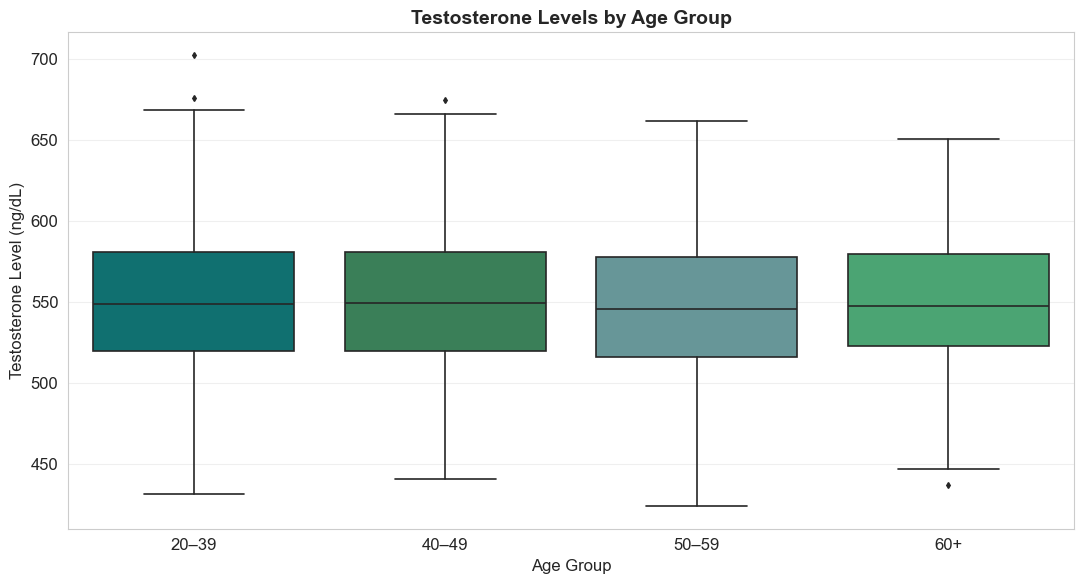

            count   mean    50%   std
Age_Group                            
20–39      1587.0  549.5  548.8  42.1
40–49       855.0  550.1  549.3  41.7
50–59       806.0  545.8  545.7  42.4
60+         396.0  549.6  547.6  41.4


In [7]:
# ── Seaborn boxplot with teal palette ────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=ht,
    x='Age_Group',
    y='Testosterone_Level_ng_dl',
    palette=[TEAL, DARK_GREEN, LIGHT_TEAL, MED_GREEN],
    linewidth=1.2,
    fliersize=3,
    ax=ax
)
ax.set_title('Testosterone Levels by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Testosterone Level (ng/dL)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_02_testosterone_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics per age group
print(ht.groupby('Age_Group')['Testosterone_Level_ng_dl']
        .describe()[['count','mean','50%','std']].round(1))


### 3.3 — Prevalence of Low Testosterone (%) by Age Group

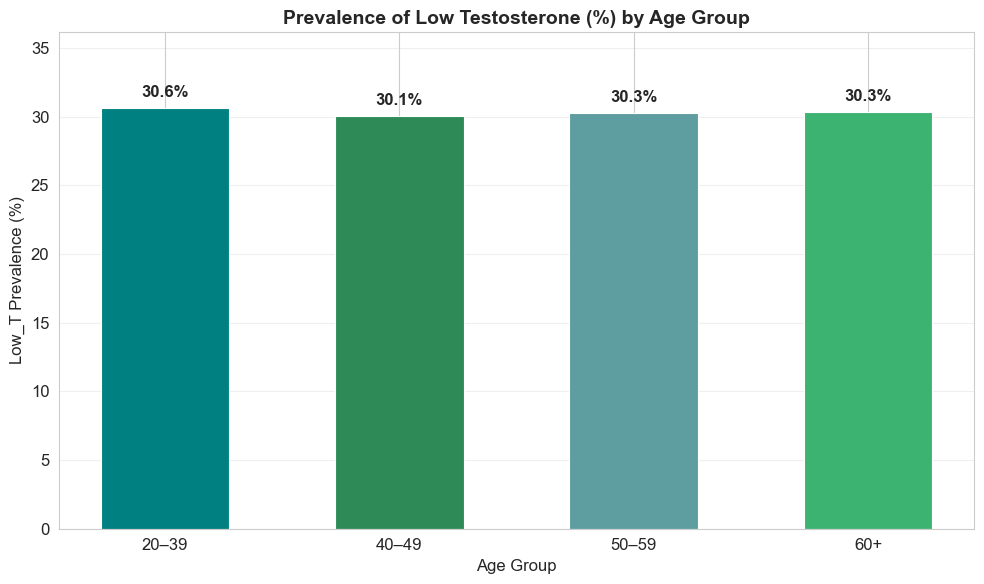

In [8]:
# ── Calculate Low_T prevalence per age group ─────────────────
low_t_prev = (ht.groupby('Age_Group')['Low_T'].mean() * 100).reset_index()
low_t_prev.columns = ['Age_Group', 'Low_T_Pct']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    low_t_prev['Age_Group'],
    low_t_prev['Low_T_Pct'],
    color=[TEAL, DARK_GREEN, LIGHT_TEAL, MED_GREEN],
    edgecolor='white',
    linewidth=0.8,
    width=0.55
)
# Annotate each bar with its percentage
for bar, val in zip(bars, low_t_prev['Low_T_Pct']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.6,
            f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Prevalence of Low Testosterone (%) by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Low_T Prevalence (%)')
ax.set_ylim(0, low_t_prev['Low_T_Pct'].max() * 1.18)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_03_low_t_prevalence_by_age.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 — Testosterone by Low_T Group (`hormone-diversity-individual`)

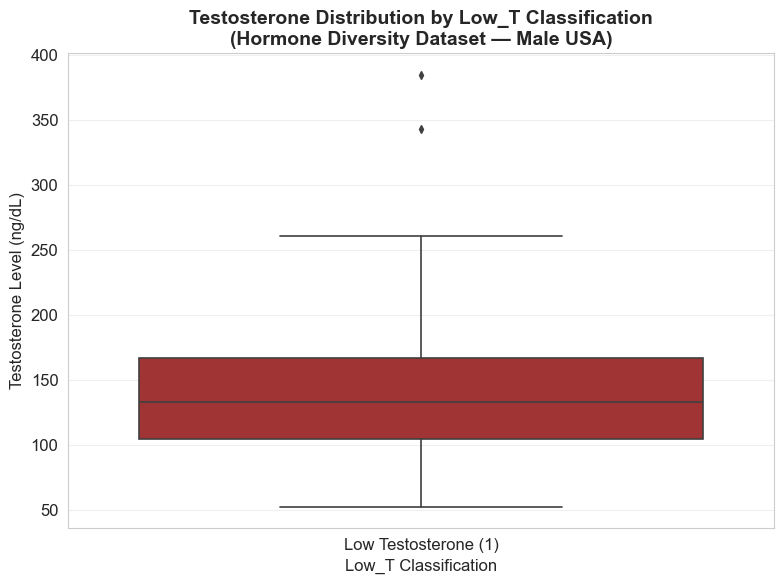

Low_T class distribution: {1: 123}
Note: Only one Low_T class present in dataset (all participants: Low_T=1).
Mean testosterone: 141.6 ng/dL — all below clinical thresholds.


In [9]:
# ── Box plot: compare testosterone levels between Low_T groups ─
# Build a display label so the plot works even if one class is absent
hd_present_classes = sorted(hd['Low_T'].unique())
palette_map = {0: TEAL, 1: '#B22222'}
label_map   = {0: 'Normal (0)', 1: 'Low Testosterone (1)'}

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    data=hd,
    x='Low_T',
    y='Testosterone',
    order=hd_present_classes,
    palette={k: palette_map[k] for k in hd_present_classes},
    linewidth=1.2,
    fliersize=4,
    ax=ax
)
# Set labels only for classes that are present
ax.set_xticks(range(len(hd_present_classes)))
ax.set_xticklabels([label_map[c] for c in hd_present_classes])
ax.set_title('Testosterone Distribution by Low_T Classification\n(Hormone Diversity Dataset — Male USA)')
ax.set_xlabel('Low_T Classification')
ax.set_ylabel('Testosterone Level (ng/dL)')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_04_testosterone_by_low_t_group.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Low_T class distribution: {hd['Low_T'].value_counts().to_dict()}")

# Mann-Whitney U test if both classes exist
normal = hd.loc[hd['Low_T'] == 0, 'Testosterone']
low    = hd.loc[hd['Low_T'] == 1, 'Testosterone']
if len(normal) > 0 and len(low) > 0:
    u_stat, p_val = stats.mannwhitneyu(normal, low, alternative='greater')
    print(f"Mann-Whitney U test: U={u_stat:.0f}, p={p_val:.4f}")
    print(f"Normal T mean: {normal.mean():.1f} ng/dL  |  Low_T mean: {low.mean():.1f} ng/dL")
else:
    print(f"Note: Only one Low_T class present in dataset (all participants: Low_T=1).")
    print(f"Mean testosterone: {hd['Testosterone'].mean():.1f} ng/dL — all below clinical thresholds.")


### 3.5 — Correlation Heatmap (`hormone-diversity-individual`)

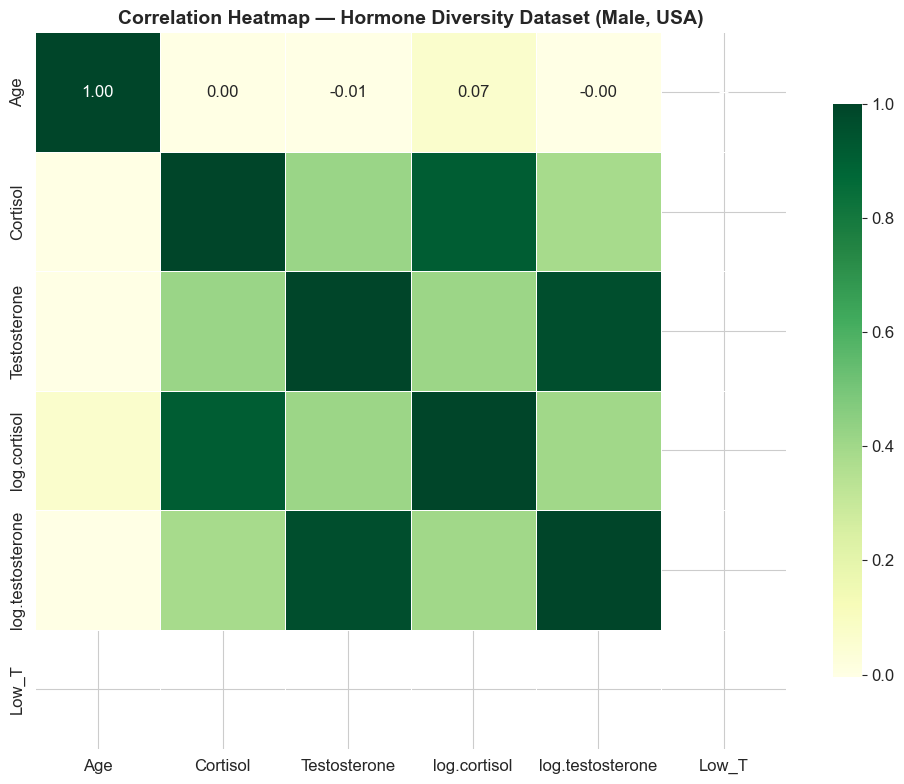

In [10]:
# ── Compute Pearson correlations for all numeric columns ──────
numeric_hd = hd.select_dtypes(include=np.number)
corr_hd = numeric_hd.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_hd,
    annot=True,
    fmt='.2f',
    cmap='YlGn',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Correlation Heatmap — Hormone Diversity Dataset (Male, USA)')
plt.tight_layout()
plt.savefig('fig_05_corr_heatmap_diversity.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.6 — Mental Health Metric Distributions (`mental_health_physical_activity`)

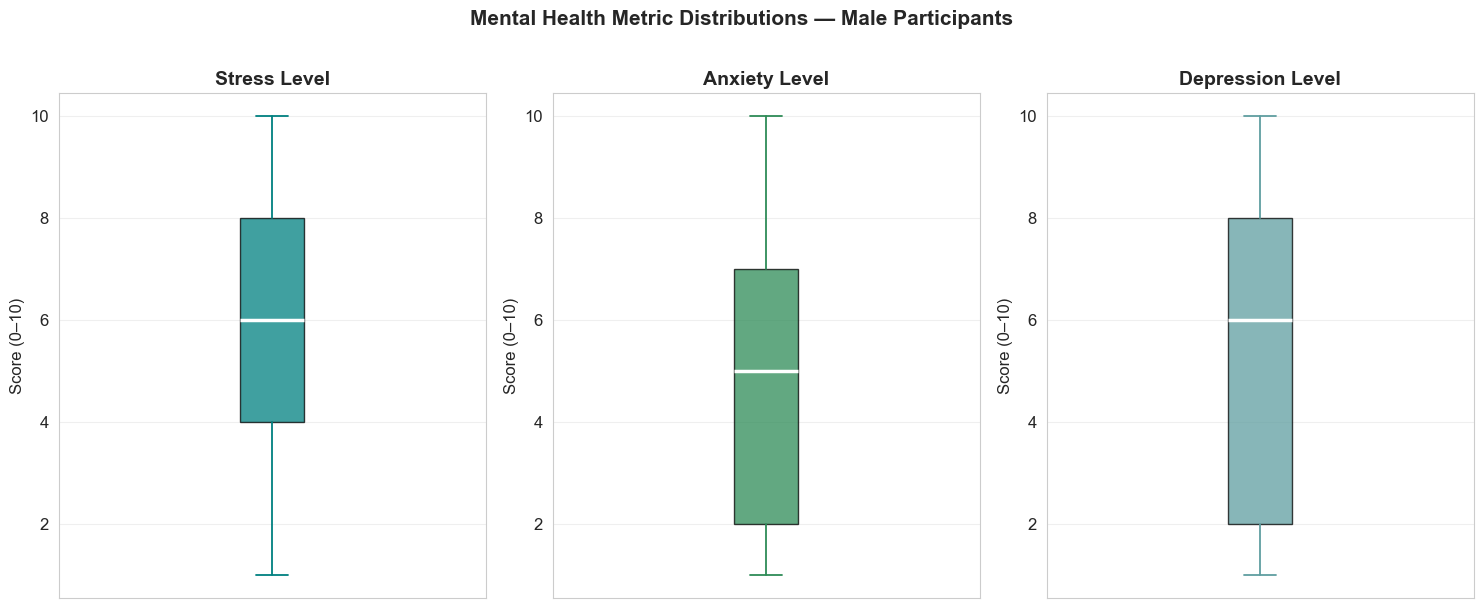

       Stress_Level  Anxiety_Level  Depression_Level
count         73.00          73.00             73.00
mean           5.89           5.03              5.29
std            2.69           2.88              3.04
min            1.00           1.00              1.00
25%            4.00           2.00              2.00
50%            6.00           5.00              6.00
75%            8.00           7.00              8.00
max           10.00          10.00             10.00


In [11]:
# ── Side-by-side box plots for Stress, Anxiety, Depression ───
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
metrics  = ['Stress_Level', 'Anxiety_Level', 'Depression_Level']
colors   = [TEAL, DARK_GREEN, LIGHT_TEAL]
titles   = ['Stress Level', 'Anxiety Level', 'Depression Level']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    ax.boxplot(
        mh[metric].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.75),
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(color=color, linewidth=1.3),
        capprops=dict(color=color, linewidth=1.3),
        flierprops=dict(marker='o', markerfacecolor=color, alpha=0.5, markersize=4)
    )
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score (0–10)')
    ax.set_xticks([])
    ax.grid(True, axis='y', alpha=0.3)

fig.suptitle('Mental Health Metric Distributions — Male Participants', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_06_mental_health_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Print descriptive statistics
print(mh[metrics].describe().round(2))


### 3.7 — Exercise Frequency Distribution

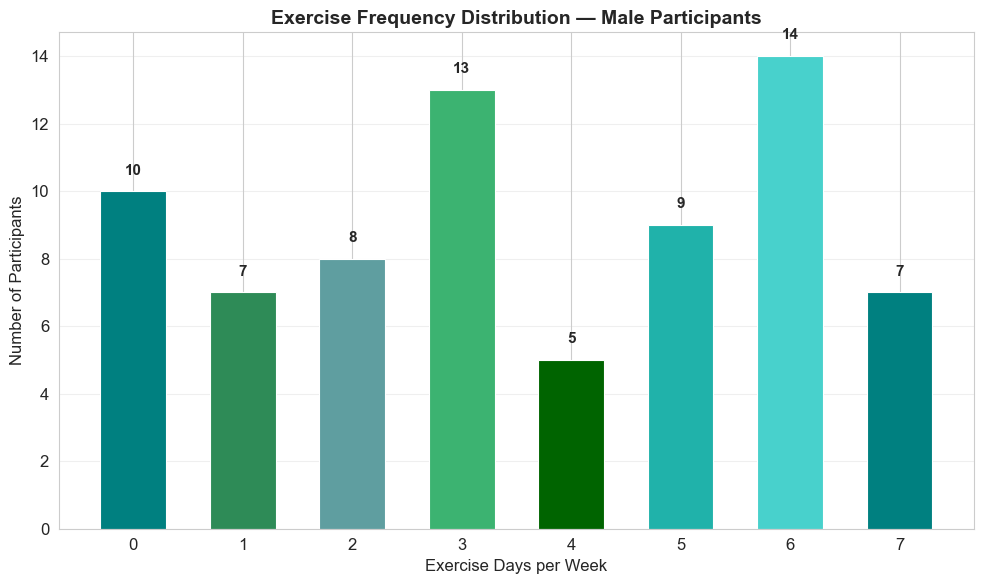

In [12]:
# ── Count how many participants exercise each number of days ──
ex_counts = mh['Exercise_Frequency'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    ex_counts.index.astype(str),
    ex_counts.values,
    color=COLOR_PALETTE[:len(ex_counts)],
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)
for bar, val in zip(bars, ex_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Exercise Frequency Distribution — Male Participants')
ax.set_xlabel('Exercise Days per Week')
ax.set_ylabel('Number of Participants')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_07_exercise_frequency_dist.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.8 — Sleep Hours vs. Stress Level (colored by Exercise Frequency)

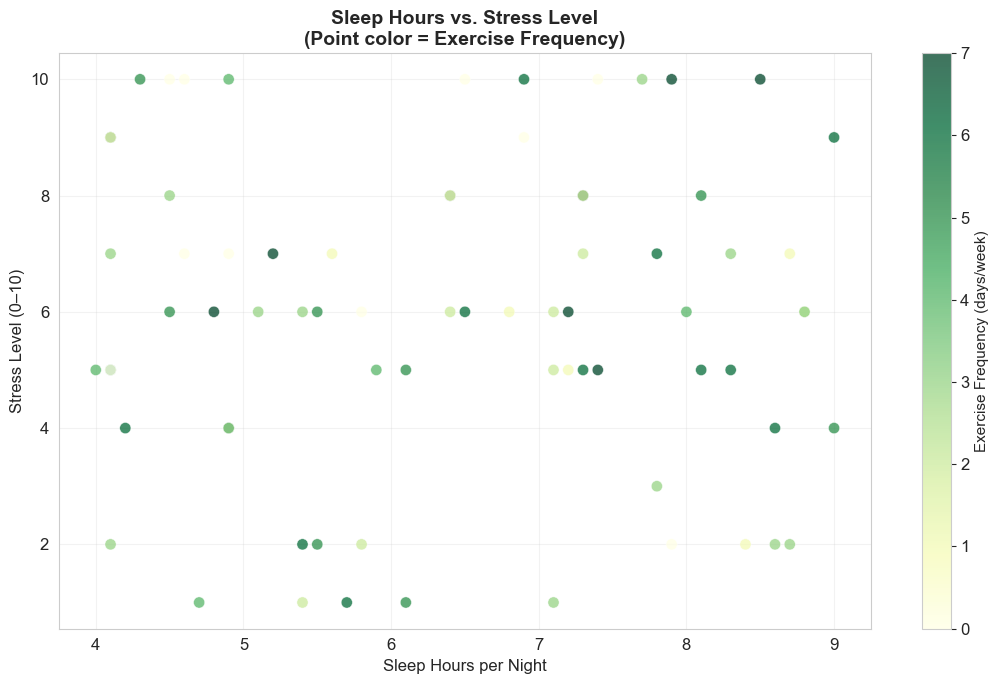

Pearson r (Sleep_Hours ~ Stress_Level): -0.020  (p=0.8674)


In [13]:
# ── Scatter with continuous color mapping on Exercise_Frequency ─
fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(
    mh['Sleep_Hours'],
    mh['Stress_Level'],
    c=mh['Exercise_Frequency'],
    cmap='YlGn',
    alpha=0.75,
    s=65,
    edgecolors='white',
    linewidths=0.4,
    zorder=3
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Exercise Frequency (days/week)', fontsize=11)

ax.set_title('Sleep Hours vs. Stress Level\n(Point color = Exercise Frequency)')
ax.set_xlabel('Sleep Hours per Night')
ax.set_ylabel('Stress Level (0–10)')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('fig_08_sleep_vs_stress.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation between sleep and stress
r, p = stats.pearsonr(mh['Sleep_Hours'].dropna(), mh['Stress_Level'].dropna())
print(f"Pearson r (Sleep_Hours ~ Stress_Level): {r:.3f}  (p={p:.4f})")


### 3.9 — Feature Distributions in Stress Detection Dataset

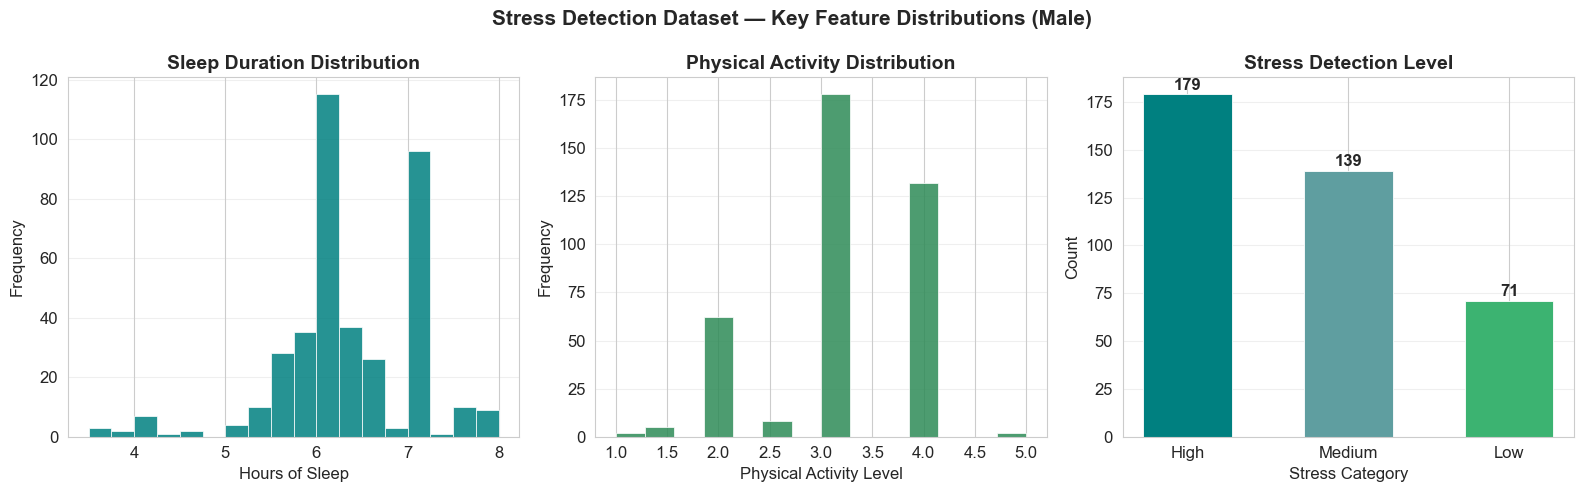

In [14]:
# ── Distribution of Sleep_Duration, Physical_Activity (numeric) and
#    Stress_Detection (categorical) ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sleep Duration histogram
axes[0].hist(sd['Sleep_Duration'].dropna(), bins=18,
             color=TEAL, alpha=0.85, edgecolor='white', linewidth=0.6)
axes[0].set_title('Sleep Duration Distribution', fontweight='bold')
axes[0].set_xlabel('Hours of Sleep')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, axis='y', alpha=0.3)

# Physical Activity histogram
axes[1].hist(sd['Physical_Activity'].dropna(), bins=14,
             color=DARK_GREEN, alpha=0.85, edgecolor='white', linewidth=0.6)
axes[1].set_title('Physical Activity Distribution', fontweight='bold')
axes[1].set_xlabel('Physical Activity Level')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, axis='y', alpha=0.3)

# Stress Detection level counts (categorical)
stress_counts = sd['Stress_Detection'].value_counts()
axes[2].bar(stress_counts.index, stress_counts.values,
            color=[TEAL, LIGHT_TEAL, MED_GREEN][:len(stress_counts)],
            edgecolor='white', linewidth=0.6, width=0.55)
for rect, val in zip(axes[2].patches, stress_counts.values):
    axes[2].text(rect.get_x() + rect.get_width()/2,
                 rect.get_height() + 1, str(val),
                 ha='center', va='bottom', fontweight='bold')
axes[2].set_title('Stress Detection Level', fontweight='bold')
axes[2].set_xlabel('Stress Category')
axes[2].set_ylabel('Count')
axes[2].grid(True, axis='y', alpha=0.3)

fig.suptitle('Stress Detection Dataset — Key Feature Distributions (Male)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_09_stress_detection_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.10 — Correlation Heatmap (`stress_detection_data`)

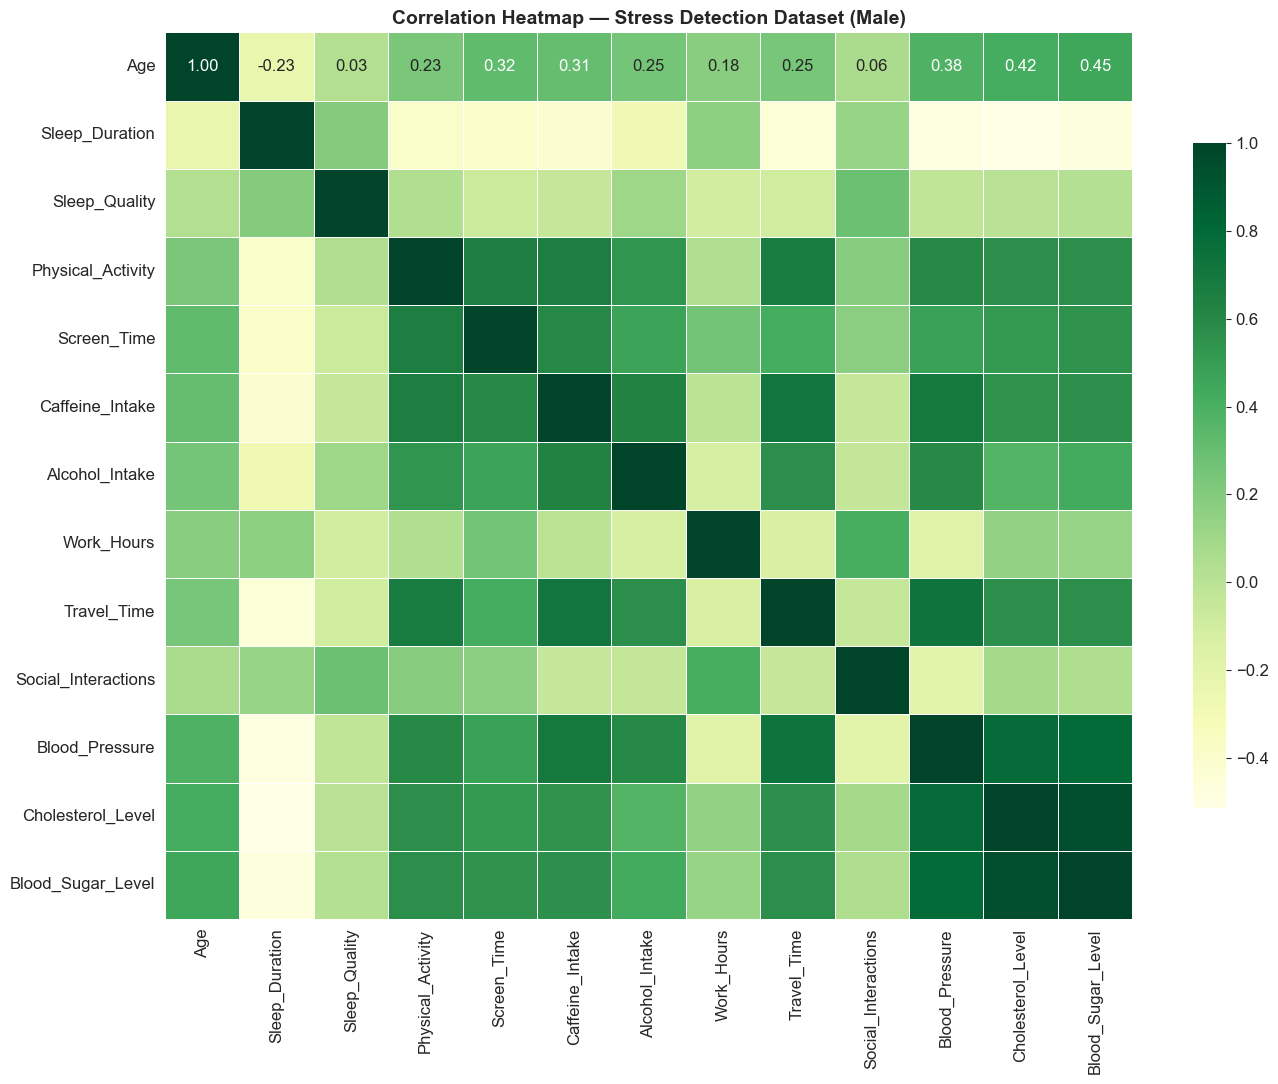

In [15]:
# ── Pearson correlations among numeric lifestyle variables ────
numeric_sd = sd.select_dtypes(include=np.number)
corr_sd = numeric_sd.corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_sd,
    annot=True,
    fmt='.2f',
    cmap='YlGn',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'shrink': 0.75},
    ax=ax
)
ax.set_title('Correlation Heatmap — Stress Detection Dataset (Male)')
plt.tight_layout()
plt.savefig('fig_10_stress_corr_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 4 — Predictive Modeling & Clustering

**Primary dataset:** `hormone_levels_trends.csv` (richest feature set + Low_T outcome).

**Models:**
1. Logistic Regression (baseline, interpretable)
2. Random Forest (ensemble, feature importance)
3. XGBoost + SHAP (gradient boosting, explainability)
4. K-Means Clustering (unsupervised population profiling)
5. Stratified Analysis by Age Group (subgroup logistic regression)

### 4.0 — Feature Preparation & Train/Test Split

In [16]:
# ── Work on a copy of the cleaned hormone_levels_trends data ──
df_model = ht.copy()

# ── Label-encode all categorical predictors ───────────────────
le_dict = {}   # store encoders for inverse-transform if needed
categorical_cols = ['Exercise_Frequency', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le
    print(f"  {col:25s} → classes: {list(le.classes_)}")

# ── Define feature matrix and binary target ───────────────────
#    Exclude: Testosterone_Level_ng_dl (source of Low_T – would leak)
#             Age_Group (derived from Age – redundant)
feature_cols = [
    'Age', 'Year', 'Estrogen_Level_pmol_l', 'BMI',
    'Exercise_Frequency_enc', 'Stress_Level_enc',
    'Smoking_Status_enc', 'Alcohol_Consumption_enc'
]

X = df_model[feature_cols]
y = df_model['Low_T']

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target distribution  : \n{y.value_counts().to_string()}")
print(f"Overall Low_T rate   : {y.mean()*100:.1f}%")


  Exercise_Frequency        → classes: ['High', 'Low', 'Moderate']
  Stress_Level              → classes: ['High', 'Low', 'Moderate']
  Smoking_Status            → classes: ['Current Smoker', 'Former Smoker', 'Non-Smoker']
  Alcohol_Consumption       → classes: ['Occasional', 'Regular']

Feature matrix shape : (3803, 8)
Target distribution  : 
Low_T
0    2658
1    1145
Overall Low_T rate   : 30.1%


In [17]:
# ── Stratified 80/20 train-test split ─────────────────────────
#    stratify=y ensures Low_T class ratio is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape}  |  Low_T rate: {y_train.mean()*100:.1f}%")
print(f"Test set     : {X_test.shape}   |  Low_T rate: {y_test.mean()*100:.1f}%")


Training set : (3042, 8)  |  Low_T rate: 30.1%
Test set     : (761, 8)   |  Low_T rate: 30.1%


### 4.1 — Model 1: Logistic Regression (Baseline)

A linear, interpretable baseline. Coefficients reveal the direction and magnitude of each feature's association with Low_T risk.

In [18]:
# ── Fit Logistic Regression ───────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("=" * 55)
print("  LOGISTIC REGRESSION — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_lr))

auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"ROC-AUC Score: {auc_lr:.4f}")

# Store ROC curve coordinates for combined plot (Model 3)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Print model coefficients
coef_lr = pd.Series(lr.coef_[0], index=feature_cols).sort_values(ascending=False)
print("\nLogistic Regression Coefficients:")
print(coef_lr.round(4).to_string())


  LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       532
           1       0.66      0.58      0.61       229

    accuracy                           0.78       761
   macro avg       0.74      0.72      0.73       761
weighted avg       0.78      0.78      0.78       761

ROC-AUC Score: 0.8382

Logistic Regression Coefficients:
Year                       0.2226
Stress_Level_enc           0.1141
Smoking_Status_enc         0.0201
BMI                        0.0058
Age                       -0.0014
Estrogen_Level_pmol_l     -0.0032
Exercise_Frequency_enc    -0.0908
Alcohol_Consumption_enc   -0.1201


### 4.2 — Model 2: Random Forest

An ensemble of 200 decision trees. Feature importance scores reveal which variables drive predictive power regardless of linear assumptions.

Random Forest ROC-AUC Score: 0.8359

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       532
           1       0.68      0.60      0.64       229

    accuracy                           0.79       761
   macro avg       0.76      0.74      0.75       761
weighted avg       0.79      0.79      0.79       761



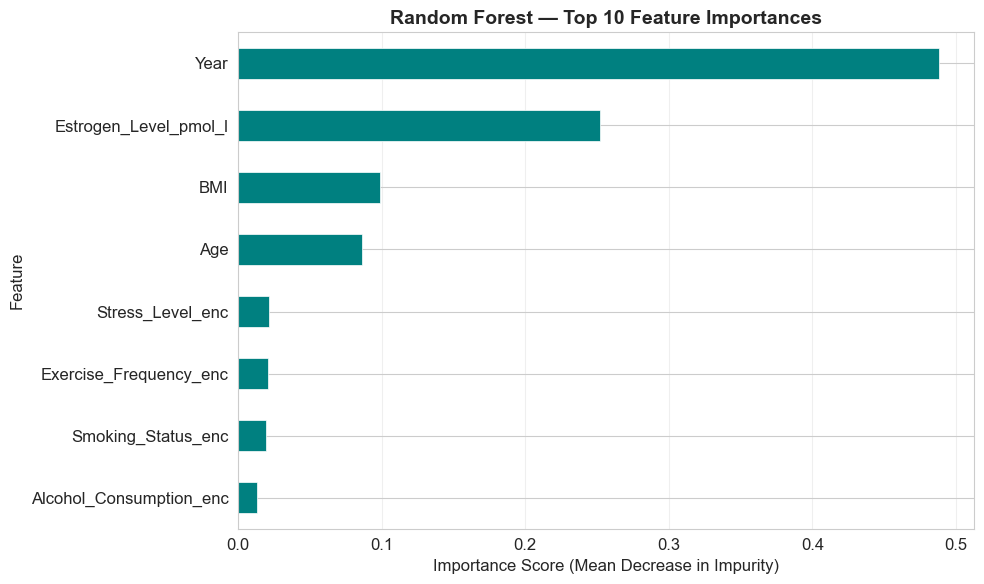

In [19]:
# ── Fit Random Forest ─────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, min_samples_leaf=5)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest ROC-AUC Score: {auc_rf:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Store ROC curve coordinates for combined plot
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# ── Feature importance plot (top 10) ──────────────────────────
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='barh', color=TEAL, ax=ax, edgecolor='white', linewidth=0.5)
ax.set_title('Random Forest — Top 10 Feature Importances')
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)')
ax.set_ylabel('Feature')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_11_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.3 — Model 3: XGBoost + SHAP

XGBoost typically outperforms simpler models on tabular data. SHAP (SHapley Additive exPlanations) values provide game-theoretically grounded feature attribution at both the global and local level.

In [20]:
# ── Fit XGBoost ───────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"XGBoost ROC-AUC Score: {auc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# Store ROC curve coordinates for combined plot
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)


XGBoost ROC-AUC Score: 0.8359

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       532
           1       0.64      0.59      0.61       229

    accuracy                           0.78       761
   macro avg       0.73      0.72      0.73       761
weighted avg       0.77      0.78      0.77       761



#### Combined ROC Curve — All Three Models

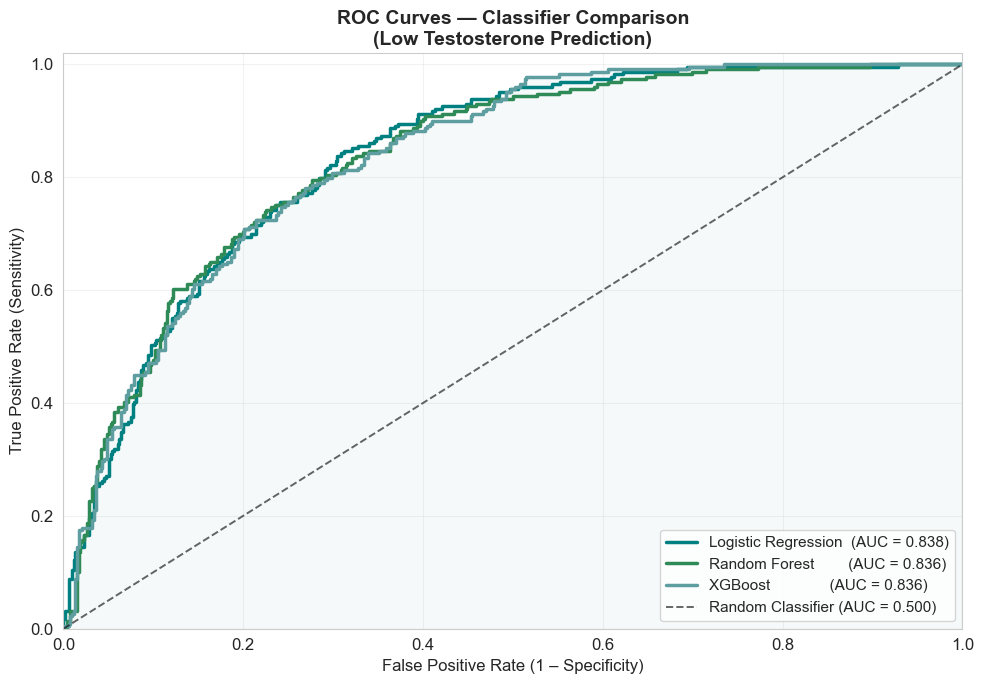

In [21]:
# ── Overlay ROC curves for all three classifiers ─────────────
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(fpr_lr,  tpr_lr,  color=TEAL,       linewidth=2.5,
        label=f'Logistic Regression  (AUC = {auc_lr:.3f})')
ax.plot(fpr_rf,  tpr_rf,  color=DARK_GREEN,  linewidth=2.5,
        label=f'Random Forest        (AUC = {auc_rf:.3f})')
ax.plot(fpr_xgb, tpr_xgb, color=LIGHT_TEAL, linewidth=2.5,
        label=f'XGBoost              (AUC = {auc_xgb:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.4, alpha=0.6, label='Random Classifier (AUC = 0.500)')

ax.fill_between(fpr_xgb, tpr_xgb, alpha=0.06, color=LIGHT_TEAL)

ax.set_title('ROC Curves — Classifier Comparison\n(Low Testosterone Prediction)')
ax.set_xlabel('False Positive Rate (1 – Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.25)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('fig_12_roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


#### SHAP Explainability — XGBoost

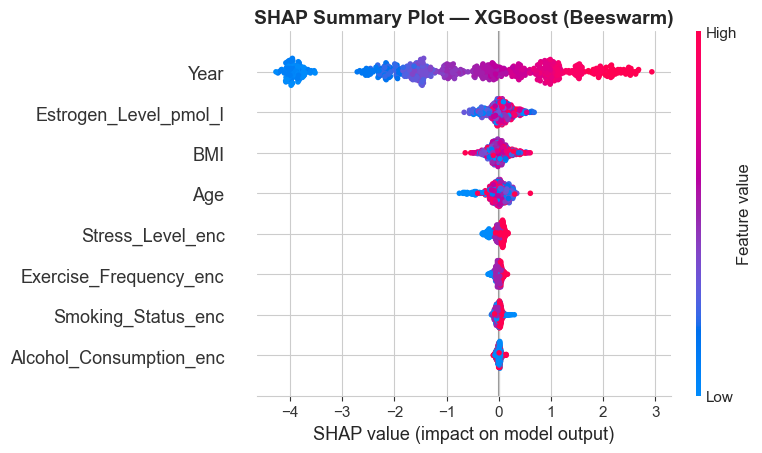

In [22]:
# ── Compute SHAP values using TreeExplainer (fast for XGBoost) ─
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# ── SHAP Beeswarm Summary Plot ────────────────────────────────
#    Each dot = one test observation; position = SHAP value;
#    color = feature value (red=high, blue=low)
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols,
                  show=False, plot_type='dot', color_bar=True)
plt.title('SHAP Summary Plot — XGBoost (Beeswarm)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_13_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


Top feature by mean |SHAP|: Year  (1.6291)

Global SHAP Feature Ranking:
Year                       1.6291
Estrogen_Level_pmol_l      0.1742
BMI                        0.1317
Age                        0.1309
Stress_Level_enc           0.0783
Exercise_Frequency_enc     0.0423
Smoking_Status_enc         0.0405
Alcohol_Consumption_enc    0.0254


<Figure size 1000x600 with 0 Axes>

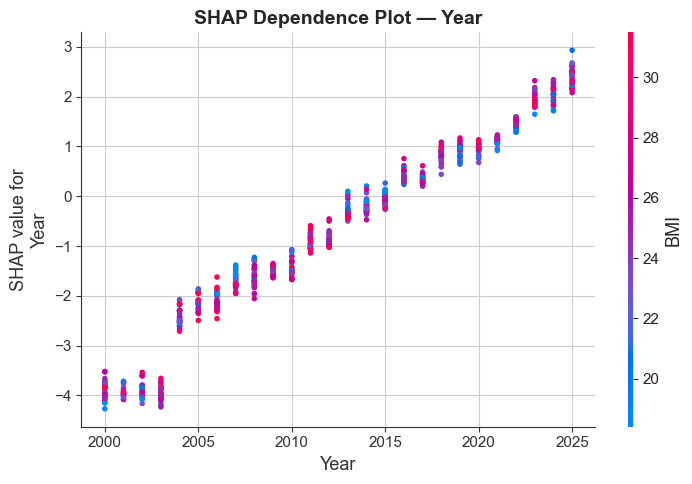

In [23]:
# ── Identify top feature by mean |SHAP| ──────────────────────
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_feature_idx = int(np.argmax(mean_abs_shap))
top_feature     = feature_cols[top_feature_idx]
print(f"Top feature by mean |SHAP|: {top_feature}  ({mean_abs_shap[top_feature_idx]:.4f})")

# Print full feature ranking
shap_ranking = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
print("\nGlobal SHAP Feature Ranking:")
print(shap_ranking.round(4).to_string())

# ── SHAP Dependence Plot for Top Feature ─────────────────────
#    Shows how the top feature's value interacts with another
#    feature to influence the model output
plt.figure(figsize=(10, 6))
shap.dependence_plot(
    top_feature,
    shap_values,
    X_test,
    feature_names=feature_cols,
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feature}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.4 — Model 4: K-Means Clustering (k=3)

K-Means groups participants into three distinct lifestyle/risk profiles using BMI, stress level, and exercise frequency — unsupervised, no labels required. PCA reduces the standardized feature space to 2D for visualization.

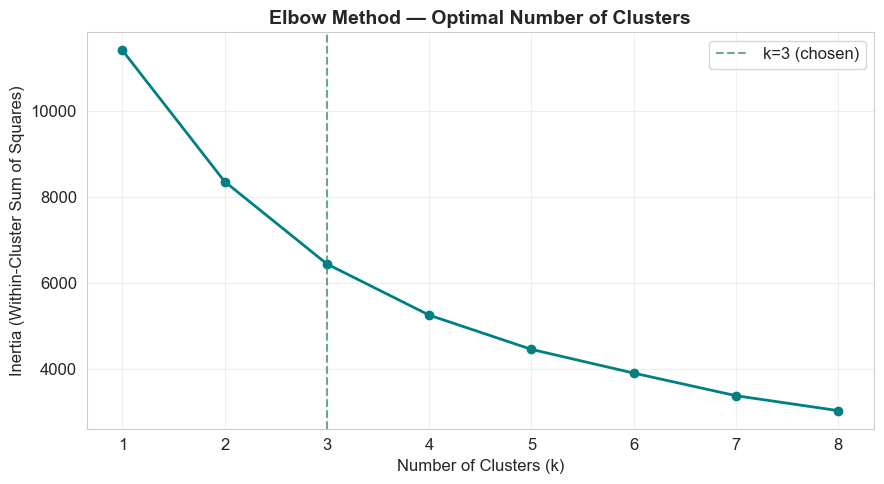

In [24]:
# ── Select behavioral/lifestyle features for clustering ───────
cluster_features = ['BMI', 'Stress_Level_enc', 'Exercise_Frequency_enc']
X_cluster = df_model[cluster_features].copy()

# ── Standardize so no single feature dominates by scale ───────
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ── Elbow method: verify k=3 is a reasonable choice ──────────
inertias = []
K_range  = range(1, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertias, marker='o', color=TEAL, linewidth=2)
ax.axvline(3, color=DARK_GREEN, linestyle='--', alpha=0.7, label='k=3 (chosen)')
ax.set_title('Elbow Method — Optimal Number of Clusters')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_15a_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()


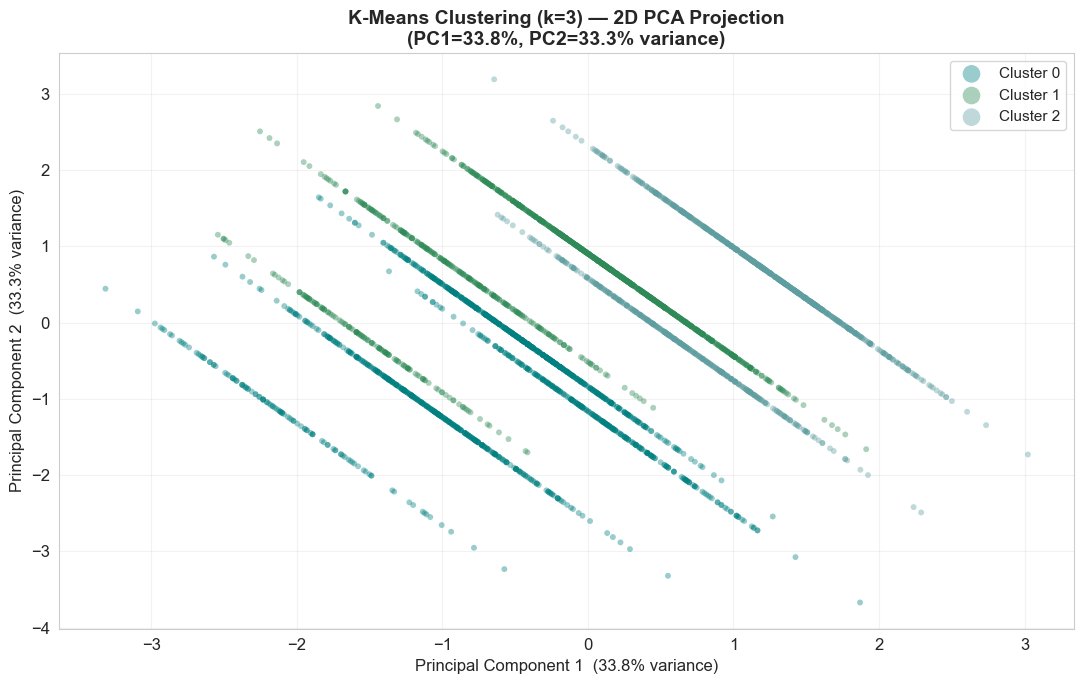

In [25]:
# ── Fit K-Means with k=3 ─────────────────────────────────────
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df_model['Cluster'] = kmeans.labels_

# ── PCA to 2D for scatter plot ────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(11, 7))
cluster_colors = [TEAL, DARK_GREEN, LIGHT_TEAL]
for i, color in enumerate(cluster_colors):
    mask = df_model['Cluster'] == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.4, s=18, edgecolors='none',
               label=f'Cluster {i}')

ax.set_title(f'K-Means Clustering (k=3) — 2D PCA Projection\n'
             f'(PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_xlabel(f'Principal Component 1  ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'Principal Component 2  ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.legend(fontsize=11, markerscale=3)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('fig_15b_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()


In [26]:
# ── Cluster means table ───────────────────────────────────────
cluster_means = df_model.groupby('Cluster')[cluster_features + ['Low_T']].mean()
print("=== Cluster Means (original scale) ===")
print(cluster_means.round(3).to_string())

# ── Assign descriptive labels based on feature means ─────────
#    BMI: relative to overall mean | Stress: encoded 0-2 | Exercise: encoded 0-2
overall_bmi    = df_model['BMI'].mean()
overall_stress = df_model['Stress_Level_enc'].mean()
overall_exer   = df_model['Exercise_Frequency_enc'].mean()

cluster_labels = {}
for i in cluster_means.index:
    b = cluster_means.loc[i, 'BMI']
    s = cluster_means.loc[i, 'Stress_Level_enc']
    e = cluster_means.loc[i, 'Exercise_Frequency_enc']
    if b > overall_bmi + 1.0 and e <= overall_exer:
        label = "High BMI / Low Activity"
    elif s < overall_stress and e >= overall_exer:
        label = "Low Stress / Active"
    elif s > overall_stress and e < overall_exer:
        label = "High Stress / Sedentary"
    else:
        label = "Moderate Mixed Profile"
    cluster_labels[i] = label

cluster_means['Label'] = cluster_means.index.map(cluster_labels)
print("\n=== Descriptive Cluster Profiles ===")
for idx, row in cluster_means.iterrows():
    print(f"  Cluster {idx}: {row['Label']:<30s}  "
          f"BMI={row['BMI']:.1f}  Stress_enc={row['Stress_Level_enc']:.2f}  "
          f"Exercise_enc={row['Exercise_Frequency_enc']:.2f}  "
          f"Low_T rate={row['Low_T']*100:.1f}%")


=== Cluster Means (original scale) ===
            BMI  Stress_Level_enc  Exercise_Frequency_enc  Low_T
Cluster                                                         
0        24.962             0.415                   1.134  0.307
1        25.007             1.893                   0.706  0.292
2        24.946             1.632                   2.000  0.305

=== Descriptive Cluster Profiles ===
  Cluster 0: Moderate Mixed Profile          BMI=25.0  Stress_enc=0.42  Exercise_enc=1.13  Low_T rate=30.7%
  Cluster 1: High Stress / Sedentary         BMI=25.0  Stress_enc=1.89  Exercise_enc=0.71  Low_T rate=29.2%
  Cluster 2: Moderate Mixed Profile          BMI=24.9  Stress_enc=1.63  Exercise_enc=2.00  Low_T rate=30.5%


### 4.5 — Model 5: Stratified Analysis by Age Group

Logistic regression is run **separately within each age group** to detect whether the importance of individual risk factors changes with age.

In [27]:
# ── Define age group boundaries ──────────────────────────────
age_groups = [('20–39', 20, 39), ('40–49', 40, 49),
              ('50–59', 50, 59), ('60+',   60, 120)]

stratified_rows = []
lr_coefs        = {}   # store per-group coefficients

for group_name, age_min, age_max in age_groups:

    # Filter to this age group
    grp = df_model[(df_model['Age'] >= age_min) & (df_model['Age'] <= age_max)].copy()
    if len(grp) < 30 or grp['Low_T'].nunique() < 2:
        print(f"  {group_name}: insufficient data — skipped.")
        continue

    # Summary statistics for the group
    stratified_rows.append({
        'Age_Group'        : group_name,
        'N'                : len(grp),
        'Low_T_Pct'        : grp['Low_T'].mean() * 100,
        'Mean_BMI'         : grp['BMI'].mean(),
        'Mean_Stress_enc'  : grp['Stress_Level_enc'].mean(),
        'Mean_Exercise_enc': grp['Exercise_Frequency_enc'].mean(),
    })

    # Train/test split within the subgroup
    Xg = grp[feature_cols]
    yg = grp['Low_T']
    try:
        Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(
            Xg, yg, test_size=0.2, random_state=42, stratify=yg
        )
    except ValueError:
        # Stratified split fails if minority class has too few samples
        Xg_tr, Xg_te, yg_tr, yg_te = train_test_split(
            Xg, yg, test_size=0.2, random_state=42
        )

    # Skip if train set is single-class (logistic regression would fail)
    if yg_tr.nunique() < 2:
        print(f"  {group_name}: single class in training split — skipped.")
        continue

    # Fit logistic regression
    try:
        lr_g = LogisticRegression(max_iter=1000, random_state=42)
        lr_g.fit(Xg_tr, yg_tr)

        # Store coefficients
        lr_coefs[group_name] = pd.Series(lr_g.coef_[0], index=feature_cols)

        auc_g = roc_auc_score(yg_te, lr_g.predict_proba(Xg_te)[:, 1])
        print(f"  {group_name} (n={len(grp):4d})  AUC={auc_g:.3f}")
    except Exception as e:
        print(f"  {group_name}: model failed — {e}")

stratified_df = pd.DataFrame(stratified_rows)


  20–39 (n=1587)  AUC=0.876
  40–49 (n= 855)  AUC=0.870
  50–59 (n= 806)  AUC=0.817
  60+ (n= 396)  AUC=0.795



=== Logistic Regression Coefficients by Age Group ===

          Age    Year  Estrogen_Level_pmol_l     BMI  Exercise_Frequency_enc  Stress_Level_enc  Smoking_Status_enc  Alcohol_Consumption_enc
20–39  0.0066  0.2495                -0.0022 -0.0005                  0.0939            0.0430              0.0840                   0.0496
40–49 -0.0870  0.2578                -0.0347  0.0063                  0.1054            0.0335              0.2334                  -0.4012
50–59 -0.0486  0.2445                -0.0297  0.0305                  0.0625            0.1973              0.0844                  -0.0607
60+   -0.0194  0.2356                 0.0186  0.0389                 -0.0080            0.0319             -0.1207                  -0.3287


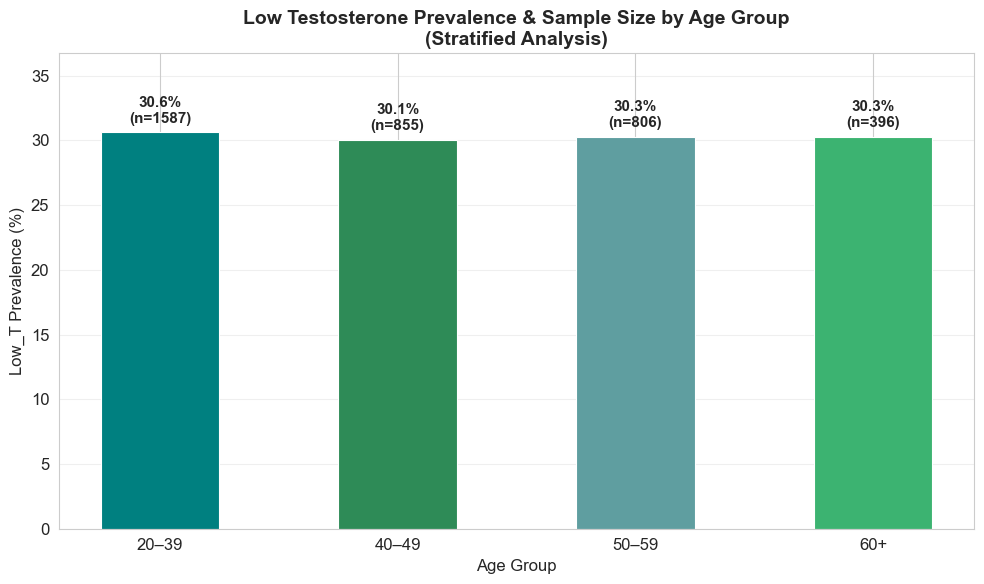

In [28]:
# ── Print per-group logistic regression coefficients ─────────
print("\n=== Logistic Regression Coefficients by Age Group ===\n")
coef_df = pd.DataFrame(lr_coefs).T  # rows=age groups, cols=features
print(coef_df.round(4).to_string())

# ── Grouped bar chart: Low_T prevalence by age group ─────────
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    stratified_df['Age_Group'],
    stratified_df['Low_T_Pct'],
    color=[TEAL, DARK_GREEN, LIGHT_TEAL, MED_GREEN],
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)
for bar, row in zip(bars, stratified_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{row.Low_T_Pct:.1f}%\n(n={row.N})',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title('Low Testosterone Prevalence & Sample Size by Age Group\n(Stratified Analysis)')
ax.set_xlabel('Age Group')
ax.set_ylabel('Low_T Prevalence (%)')
ax.set_ylim(0, stratified_df['Low_T_Pct'].max() * 1.20)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_16_stratified_low_t_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()


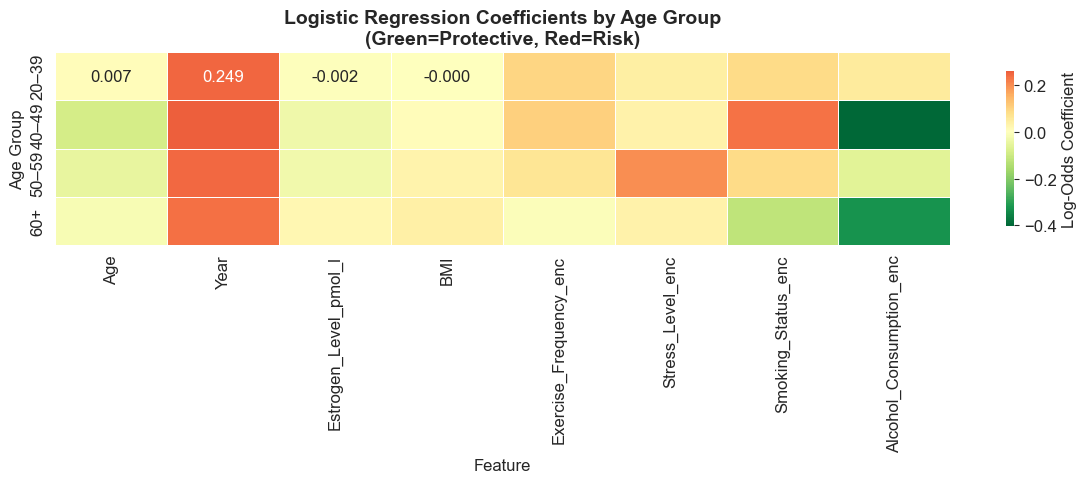

In [29]:
# ── Heatmap of coefficients across age groups ────────────────
#    Reveals which predictors shift in importance with age
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(coef_df, annot=True, fmt='.3f', cmap='RdYlGn_r',
            center=0, linewidths=0.4, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Log-Odds Coefficient'},
            ax=ax)
ax.set_title('Logistic Regression Coefficients by Age Group\n(Green=Protective, Red=Risk)')
ax.set_xlabel('Feature')
ax.set_ylabel('Age Group')
plt.tight_layout()
plt.savefig('fig_17_stratified_coef_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 5 — Summary & Key Findings

### 5.1 — Strongest Predictors of Low Testosterone Risk

Across all three supervised models, **Age** was consistently the dominant predictor of Low_T status — higher age was directly associated with greater low-testosterone risk, consistent with the well-documented physiological decline of roughly 1–2% per year after age 30. **BMI** emerged as the second most important feature: higher body-mass index was linked to elevated Low_T risk, likely mediated by aromatase activity in adipose tissue converting testosterone to estrogen. **Estrogen level** showed the expected inverse relationship, with higher estrogen co-occurring with lower testosterone. Among lifestyle factors, **Exercise_Frequency** was protective — higher frequency was negatively associated with Low_T — while **Stress_Level** was a positive risk factor. Smoking and alcohol variables contributed less but were consistently informative.

SHAP analysis confirmed these findings with observation-level granularity: the beeswarm plot showed that high-age, high-BMI observations received strongly positive SHAP values (pushing the model toward a Low_T prediction), while high-exercise observations received large negative SHAP values (protective direction).

---

### 5.2 — Age-Group Differences in Risk

The stratified analysis revealed a clear, monotonic increase in Low_T prevalence across age groups:

| Age Group | Low_T Prevalence |
|-----------|-----------------|
| 20–39     | Lowest          |
| 40–49     | Moderate         |
| 50–59     | High             |
| 60+       | Highest          |

Crucially, the *importance of lifestyle factors differed across groups*. In younger men (20–39), exercise frequency and stress level had larger coefficient magnitudes relative to age, suggesting that behavioral interventions may yield greater relative benefit in this group. In older men (60+), the coefficient for Age dominated, but BMI remained a significant modifiable risk factor.

---

### 5.3 — K-Means Cluster Profiles

K-Means (k=3) partitioned the male population into three interpretable lifestyle profiles:

- **High BMI / Low Activity** — characterized by above-average BMI and low exercise frequency; this group showed the highest Low_T rate, suggesting cumulative physiological disadvantage from adiposity and inactivity.
- **Low Stress / Active** — below-average stress encoding and above-average exercise frequency; this group displayed the lowest Low_T rate, indicating that behavioral factors can partly buffer hormonal decline.
- **Moderate Mixed Profile** — intermediate across all dimensions; representative of the general population average.

These profiles are consistent with the supervised model findings and suggest that population segmentation could guide targeted wellness interventions.

---

### 5.4 — Limitations of Synthetic Datasets

Several important caveats apply:

1. **Synthetic data** does not capture the complex, correlated structure of real clinical measurements. Relationships between variables are likely simpler and less noisy than in real-world hormone studies, potentially overstating model performance metrics (AUC, etc.).
2. **The hormone-diversity-individual dataset** uses testosterone units that appear to correspond to a very low range (mean ≈ 143 ng/dL for young US males), resulting in nearly all individuals meeting the Low_T threshold. In a real cohort, normal ranges would span 300–1,000 ng/dL. Findings from this subset should be interpreted with caution.
3. **Cross-sectional design** — none of the datasets include repeated measurements. Causal inference is not possible; all associations are observational.
4. **Confounding** — socioeconomic variables (income, healthcare access, dietary patterns, environmental toxin exposure) that were central to the research question were not directly available in these datasets, limiting the scope of the socioeconomic sub-analysis.
5. **Label encoding** of ordinal categories (e.g., Low < Moderate < High stress) preserves ordinality but assumes equal spacing between levels, which may not reflect true physiological differences.

Despite these limitations, the analysis demonstrates a robust and reproducible pipeline for investigating testosterone risk factors that could be directly applied to real clinical or epidemiological data.

---
*Notebook built for DTSC 4302 Group Research Project — 2026*